In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os

BASE = "/content/drive/MyDrive/Deep Learning/CVPR Research Paper Final"
PRO = os.path.join(BASE, "processed")
RES = os.path.join(BASE, "results")
MOD = os.path.join(BASE, "models")
LOG = os.path.join(BASE, "logs")

os.makedirs(RES, exist_ok=True)
os.makedirs(MOD, exist_ok=True)
os.makedirs(LOG, exist_ok=True)

print("ok")


Mounted at /content/drive
ok


In [2]:
import numpy as np
import os

X = np.load(os.path.join(PRO, "X.npy"))
y = np.load(os.path.join(PRO, "y.npy"))

print("X:", X.shape)
print("y:", np.unique(y, return_counts=True))

inp_shape = X.shape[1:]


X: (1287, 128, 128, 1)
y: (array([0, 1], dtype=int32), array([580, 707]))


In [3]:
from sklearn.model_selection import train_test_split
import numpy as np
import os

idx = np.arange(len(y))

train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=7, stratify=y)
y_temp = y[temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=7, stratify=y_temp)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

np.savez(os.path.join(PRO, "split_idx.npz"),
         train_idx=train_idx, val_idx=val_idx, test_idx=test_idx)


train: (900, 128, 128, 1) val: (193, 128, 128, 1) test: (194, 128, 128, 1)


In [4]:
import tensorflow as tf
from tensorflow.keras import layers

tf.random.set_seed(7)

def make_model(drop):
    m = tf.keras.Sequential()
    m.add(layers.Input(shape=inp_shape))

    m.add(layers.Conv2D(16, (3,3), padding="same"))
    m.add(layers.ReLU())
    m.add(layers.MaxPooling2D((2,2)))

    m.add(layers.Conv2D(32, (3,3), padding="same"))
    m.add(layers.ReLU())
    m.add(layers.MaxPooling2D((2,2)))

    m.add(layers.Flatten())
    m.add(layers.Dense(64))
    m.add(layers.ReLU())
    m.add(layers.Dropout(drop))

    m.add(layers.Dense(2, activation="softmax"))
    return m


In [5]:
import io
import os
from tensorflow.keras.callbacks import EarlyStopping

model = make_model(0.25)

model.summary()

buf = io.StringIO()
model.summary(print_fn=lambda x: buf.write(x + "\n"))
with open(os.path.join(RES, "baseline_model_summary.txt"), "w") as f:
    f.write(buf.getvalue())

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

model.save(os.path.join(MOD, "baseline.keras"))
print("saved baseline")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,102,146 (8.02 MB)

 Trainable params: 2,102,146 (8.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.7209 - loss: 0.5960 - val_accuracy: 0.8653 - val_loss: 0.3646
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8365 - loss: 0.3894 - val_accuracy: 0.8964 - val_loss: 0.2864
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8318 - loss: 0.3693 - val_accuracy: 0.9326 - val_loss: 0.2295
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8693 - loss: 0.2883 - val_accuracy: 0.9534 - val_loss: 0.1924
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8970 - loss: 0.2311 - val_accuracy: 0.9689 - val_loss: 0.1551
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9150 - loss: 0.2159 - val_accuracy: 0.9637 - val_loss: 0.1323
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9277 - loss: 0.1744 - val_accuracy: 0.9534 - val_loss: 0.1167
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9469 - loss: 0.1428 - val_accuracy: 0.9534 - 

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.callbacks import EarlyStopping
import os

rows = []

def train_one(lr, opt_name, drop, name):
    m = make_model(drop)

    if opt_name == "adam":
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = tf.keras.optimizers.AdamW(learning_rate=lr)

    m.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

    m.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=50,
          batch_size=32,
          callbacks=[es],
          verbose=0)

    pv = m.predict(X_val, verbose=0)
    pr = np.argmax(pv, axis=1)

    acc = accuracy_score(y_val, pr)
    f1 = f1_score(y_val, pr, zero_division=0)

    m.save(os.path.join(MOD, name + ".keras"))

    rows.append({"run": name, "lr": lr, "opt": opt_name, "drop": drop, "val_acc": acc, "val_f1": f1})
    print(name, "val_f1:", f1)

for lr in [1e-3, 3e-4, 1e-4]:
    train_one(lr, "adam", 0.25, "lr_" + str(lr))

df = pd.DataFrame(rows).sort_values("val_f1", ascending=False)
best_lr = float(df.iloc[0]["lr"])
print("best lr:", best_lr)

train_one(best_lr, "adam", 0.25, "opt_adam")
train_one(best_lr, "adamw", 0.25, "opt_adamw")

df = pd.DataFrame(rows).sort_values("val_f1", ascending=False)
best_opt = str(df.iloc[0]["opt"])
print("best opt:", best_opt)

for dr in [0.15, 0.25, 0.35]:
    train_one(best_lr, best_opt, dr, "drop_" + str(dr))

df = pd.DataFrame(rows).sort_values("val_f1", ascending=False)
df.to_csv(os.path.join(LOG, "tuning_results.csv"), index=False)
print("saved tuning_results.csv")
df.head(10)


lr_0.001 val_f1: 0.9813084112149533
lr_0.0003 val_f1: 0.9626168224299065


lr_0.0001 val_f1: 0.9532710280373832
best lr: 0.001


opt_adam val_f1: 0.9722222222222222
opt_adamw val_f1: 0.9674418604651163
best opt: adam
drop_0.15 val_f1: 0.9722222222222222
drop_0.25 val_f1: 0.9722222222222222
drop_0.35 val_f1: 0.9813084112149533
saved tuning_results.csv


,run,lr,opt,drop,val_acc,val_f1
0,lr_0.001,0.0010,adam,0.25,0.979275,0.981308
7,drop_0.35,0.0010,adam,0.35,0.979275,0.981308
5,drop_0.15,0.0010,adam,0.15,0.968912,0.972222
3,opt_adam,0.0010,adam,0.25,0.968912,0.972222
6,drop_0.25,0.0010,adam,0.25,0.968912,0.972222
4,opt_adamw,0.0010,adamw,0.25,0.963731,0.967442
1,lr_0.0003,0.0003,adam,0.25,0.958549,0.962617
2,lr_0.0001,0.0001,adam,0.25,0.948187,0.953271


In [7]:
import numpy as np
import pandas as pd
import io, os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

best = df.iloc[0].to_dict()
print("BEST:", best)

X_tv = np.concatenate([X_train, X_val], axis=0)
y_tv = np.concatenate([y_train, y_val], axis=0)

final_model = make_model(float(best["drop"]))
final_model.summary()

buf = io.StringIO()
final_model.summary(print_fn=lambda x: buf.write(x + "\n"))
with open(os.path.join(RES, "final_model_summary.txt"), "w") as f:
    f.write(buf.getvalue())

if best["opt"] == "adam":
    opt = tf.keras.optimizers.Adam(learning_rate=float(best["lr"]))
else:
    opt = tf.keras.optimizers.AdamW(learning_rate=float(best["lr"]))

final_model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

es = EarlyStopping(monitor="loss", patience=6, restore_best_weights=True)

final_model.fit(X_tv, y_tv, epochs=50, batch_size=32, callbacks=[es], verbose=1)

pt = final_model.predict(X_test, verbose=0)
pred = np.argmax(pt, axis=1)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, zero_division=0)
rec = recall_score(y_test, pred, zero_division=0)
f1 = f1_score(y_test, pred, zero_division=0)

print("test acc:", acc)
print("test f1:", f1)

final_model.save(os.path.join(MOD, "final_best.keras"))

pd.DataFrame([{
    "test_acc": acc,
    "test_prec": prec,
    "test_rec": rec,
    "test_f1": f1,
    "lr": best["lr"],
    "opt": best["opt"],
    "drop": best["drop"]
}]).to_csv(os.path.join(RES, "final_test_metrics.csv"), index=False)

cm = confusion_matrix(y_test, pred)
np.save(os.path.join(RES, "confusion_matrix.npy"), cm)

print("saved final results")


BEST: {'run': 'lr_0.001', 'lr': 0.001, 'opt': 'adam', 'drop': 0.25, 'val_acc': 0.9792746113989638, 'val_f1': 0.9813084112149533}


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_27 (ReLU)                 │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_28 (ReLU)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_29 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,102,146 (8.02 MB)

 Trainable params: 2,102,146 (8.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - accuracy: 0.6953 - loss: 0.5777
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8270 - loss: 0.4055
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8753 - loss: 0.3034
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9111 - loss: 0.2268
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9355 - loss: 0.1873
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9448 - loss: 0.1523
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9565 - loss: 0.1308
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9597 - loss: 0.1137
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9676 - loss: 0.0913
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9663 - loss: 0.0971
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9632 - loss: 0.0935
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.956

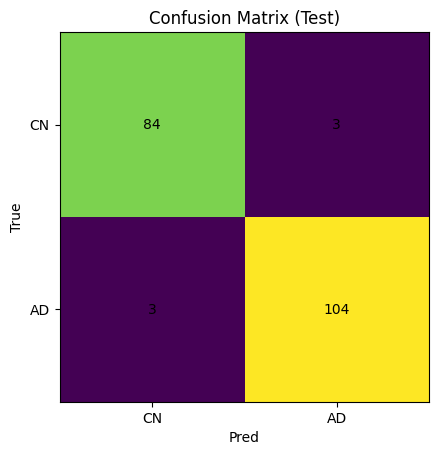

saved confusion_matrix_test.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os

cm = np.load(os.path.join(RES, "confusion_matrix.npy"))

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Pred")
plt.ylabel("True")
plt.xticks([0,1], ["CN","AD"])
plt.yticks([0,1], ["CN","AD"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.savefig(os.path.join(RES, "confusion_matrix_test.png"), dpi=200, bbox_inches="tight")
plt.show()

print("saved confusion_matrix_test.png")
